# Collision Geocoding

I want to see if collisions (in this case, intersection collisions), contain textual data that matches their nearest centreline feature (in this case, intersections).

## Steps to take
1. Initialize collision and intersection data from the source CSVs
2. Many entries in collision data share `collision_id`. Must filter to unique entries.
3. Extract only the relevant columns:
    - Collision data: `collision_id`, `stname1`, `stname2`, `stname3`, `accdate`, `accloc`, `latitude`, `longitude`
    - Intersection data: `intersection_id`, `intersection_desc`, `geometry`
4. Filter collision data even further to only collisions with null `stname3`.
5. Convert both collision data and intersection data into geodataframes, with same crs.
6. Perform sjoin_nearest to efficiently map collisions with their nearest intersection, and display distance in new column.
7. Output fuzzy matching scores on `stname1` + `stname2` and `intersection_desc`
8. Plot fuzzy scores and distance

In [1]:
%pip install geopandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 342.5/342.5 kB 1.8 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 7.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 10.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 13.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 14.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 16.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 kB 11.2 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#importing necessary libraries

import geopandas as gpd
import pandas as pd


In [37]:
# Initialize the collision data
collision_data = pd.read_csv('../data/collisions.csv')
collision_data = collision_data.drop_duplicates(subset='collision_id')
collision_data = collision_data[['collision_id', 'stname1', 'stname2', 'stname3', 'latitude', 'longitude']]
collision_data.head()

,collision_id,stname1,stname2,stname3,latitude,longitude
0,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798
8,2006:909646,DANFORTH AVE,WEST LYNN AVE,NaN,43.684873,-79.316189
13,2006:884090,BATHURST ST,DUNDAS ST W,60 NORTH OF,43.652891,-79.406254
15,2006:885782,DUFFERIN ST,SYLVAN AVE,NaN,43.655144,-79.433591
17,2006:882079,DON MILLS RD,LEITH HILL RD,NaN,43.777055,-79.347859


In [ ]:
from shapely.geometry import shape
import json

# Initialize the intersection data
intersection_data = pd.read_csv('../data/intersections.csv')

intersection_data = intersection_data[['INTERSECTION_ID', 'INTERSECTION_DESC', 'geometry']]

intersection_data["geometry"] = intersection_data["geometry"].apply(lambda x: shape(json.loads(x)))
intersection_data = gpd.GeoDataFrame(intersection_data, geometry='geometry', crs="EPSG:4326")

# Some of the geometry are multipoints, will fix those
def to_point(geom):
    if geom.geom_type == "Point":
        return geom
    elif geom.geom_type == "MultiPoint":
        return list(geom.geoms)[0]  # take first point
    else:
        return None  # or raise error

intersection_data['geometry'] = intersection_data['geometry'].apply(lambda x: to_point(x))

intersection_data.head()

,INTERSECTION_ID,INTERSECTION_DESC,geometry
0,13469747,Grand Ave / Melrose St / Grand Avenue Park Trl,POINT (-79.49187 43.62171)
1,60002226,Grand Avenue Park Trl,POINT (-79.4903 43.62348)
2,60001952,Grand Avenue Park Trl,POINT (-79.49159 43.62268)
3,13469507,Mill Rd / Markland Dr,POINT (-79.57293 43.62729)
4,13469459,Markland Dr / Mountain Ash Crt,POINT (-79.57172 43.62819)


In [41]:
# Separate intersection collisions from the rest of the collisions
intersection_collisions = collision_data[collision_data['stname3'].isnull()]
intersection_collisions = gpd.GeoDataFrame(intersection_collisions, geometry=gpd.points_from_xy(intersection_collisions.longitude, intersection_collisions.latitude), crs="EPSG:4326")

In [42]:
# Reproject both datasets to a common CRS (e.g., EPSG:32617 for UTM zone 17N)
intersection_data = intersection_data.to_crs(epsg=32617)
intersection_collisions = intersection_collisions.to_crs(epsg=32617)

In [49]:
# Merge the collision data with the intersection data
merged_data = gpd.sjoin_nearest(intersection_collisions, intersection_data, distance_col="distance")
merged_data['location_desc'] = merged_data['stname1'] + " / " + merged_data['stname2']
merged_data['location_desc'] = merged_data['location_desc'].str.lower()
merged_data['INTERSECTION_DESC'] = merged_data['INTERSECTION_DESC'].str.lower()
merged_data.head()

,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,INTERSECTION_ID,INTERSECTION_DESC,distance,location_desc
0,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (635468.037 4839881.61),11335,13458111,woodbine ave / ventnor ave,37.820986,woodbine ave / o connor dr
8,2006:909646,DANFORTH AVE,WEST LYNN AVE,NaN,43.684873,-79.316189,POINT (635711.468 4838250.902),19154,13460669,danforth ave / west lynn ave,8.191054,danforth ave / west lynn ave
15,2006:885782,DUFFERIN ST,SYLVAN AVE,NaN,43.655144,-79.433591,POINT (626311.334 4834763.695),8411,30057152,dufferin st / dufferin grove park trl,5.863669,dufferin st / sylvan ave
17,2006:882079,DON MILLS RD,LEITH HILL RD,NaN,43.777055,-79.347859,POINT (632954.772 4848437.73),24411,13446349,don mills rd / leith hill rd,8.752709,don mills rd / leith hill rd
18,2006:890220,ADELAIDE ST E,EASTERN DIVERSION AVE,NaN,43.655344,-79.355191,POINT (632632.97 4834908.226),17808,30033294,adelaide st e / lower river st,39.417090,adelaide st e / eastern diversion ave


In [44]:
%pip install rapidfuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 11.2 MB/s eta 0:00:0000:0100:01
Note: you may need to restart the kernel to use updated packages.


In [50]:
from rapidfuzz import process, fuzz

scores = process.cdist(merged_data['location_desc'], merged_data['INTERSECTION_DESC'], scorer=fuzz.token_sort_ratio)
merged_data['match_score'] = scores.diagonal()
merged_data.head()



,collision_id,stname1,stname2,stname3,latitude,longitude,geometry,index_right,INTERSECTION_ID,INTERSECTION_DESC,distance,location_desc,match_score
0,2006:893184,WOODBINE AVE,O CONNOR DR,NaN,43.699594,-79.318798,POINT (635468.037 4839881.61),11335,13458111,woodbine ave / ventnor ave,37.820986,woodbine ave / o connor dr,73.076920
8,2006:909646,DANFORTH AVE,WEST LYNN AVE,NaN,43.684873,-79.316189,POINT (635711.468 4838250.902),19154,13460669,danforth ave / west lynn ave,8.191054,danforth ave / west lynn ave,100.000000
15,2006:885782,DUFFERIN ST,SYLVAN AVE,NaN,43.655144,-79.433591,POINT (626311.334 4834763.695),8411,30057152,dufferin st / dufferin grove park trl,5.863669,dufferin st / sylvan ave,55.737705
17,2006:882079,DON MILLS RD,LEITH HILL RD,NaN,43.777055,-79.347859,POINT (632954.772 4848437.73),24411,13446349,don mills rd / leith hill rd,8.752709,don mills rd / leith hill rd,100.000000
18,2006:890220,ADELAIDE ST E,EASTERN DIVERSION AVE,NaN,43.655344,-79.355191,POINT (632632.97 4834908.226),17808,30033294,adelaide st e / lower river st,39.417090,adelaide st e / eastern diversion ave,68.656715


In [52]:
%pip install matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.2 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.5/117.5 kB 2.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 5.1 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 362.6/362.6 kB 6.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 8.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 7.7 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 9.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 kB 8.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


<Axes: >

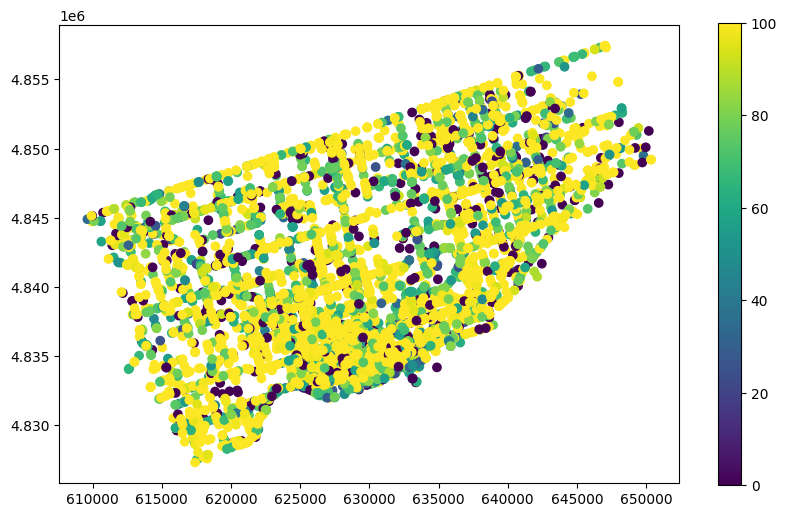

In [53]:
merged_data.plot(column='match_score', figsize=(10, 6), legend=True)

<Axes: >

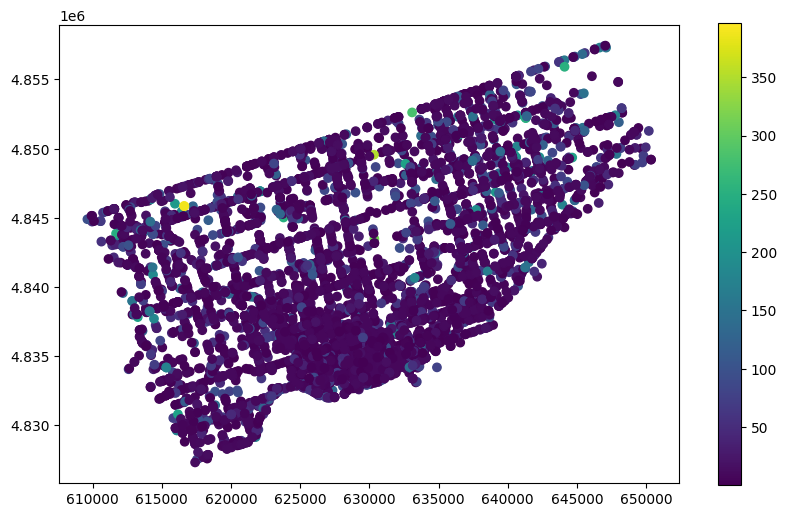

In [54]:
merged_data.plot(column='distance', figsize=(10, 6), legend=True)

<Axes: xlabel='match_score', ylabel='distance'>

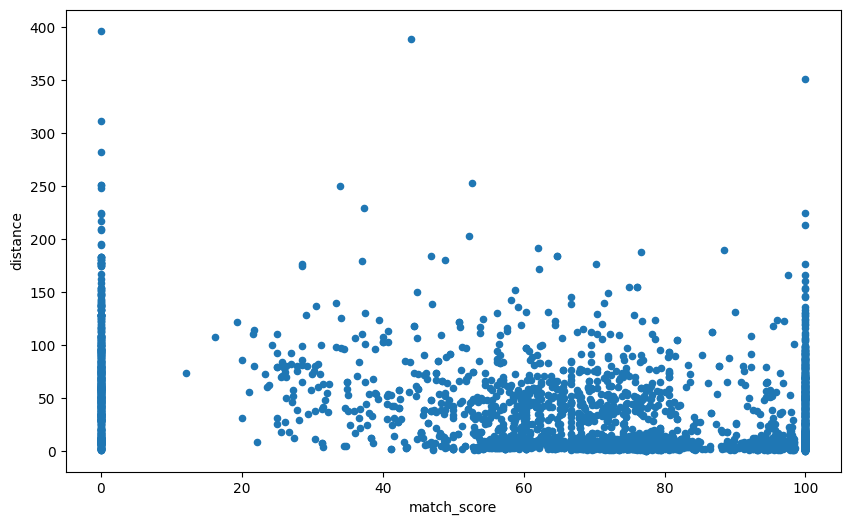

In [59]:
merged_data[['match_score', 'distance']].plot.scatter(x='match_score', y='distance', figsize=(10, 6))

In [61]:
merged_data[['match_score', 'distance']].describe()

,match_score,distance
count,5762.000000,5762.000000
mean,80.018669,21.923780
std,30.174509,34.669205
min,0.000000,0.165136
25%,70.227144,3.355780
50%,100.000000,7.731968
75%,100.000000,24.149156
max,100.000000,396.500253


Things to note:
- 25% of the collisions have a match_score less than 70. This means that 75% of the collisions have a match_score of at least 70, which according to rapidfuzz, is indicative of a good match. This shows that majority of collisions are tagged to their nearest intersection.
- 75% of the collisions are within 24.15 m of the closest intersection. This means majority of the collisions can be classified as intersection-related collisions.
- Combining the two previous points, we can conclude that majority (roughly 75%) of collisions are right where they should be.